In [1]:
import pandas as pd
import plotly.express as px

In [2]:
f = '../data/abandono_escolar/conjunto_de_datos/Educacion_11.csv'
desercion = pd.read_csv(f)

In [3]:
desercion

,Entidad federativa,Nivel educativo,2000/2001,2005/2006,2010/2011,2015/2016,2020/2021,2021/2022,2022/2023,2023/2024
0,Estados Unidos Mexicanos,Primaria,1.9,1.3,0.7,0.7,0.5,0.2,0.1,0.6
1,Estados Unidos Mexicanos,Secundaria,8.3,7.7,5.6,4.4,2.9,3.9,3.2,3.7
2,Estados Unidos Mexicanos,Media superior,17.5,16.5,14.9,15.5,11.6,10.2,11.2,11.3
3,Estados Unidos Mexicanos,Superior,8.2,7.6,7.1,7.0,8.8,8.1,7.2,7.1
4,Aguascalientes,Primaria,1.5,1.6,-0.2,0.2,0.7,0.4,0.0,1.4
...,...,...,...,...,...,...,...,...,...,...
127,Yucatán,Superior,5.1,6.4,9.7,8.3,6.3,10.3,13.6,10.0
128,Zacatecas,Primaria,2.1,1.4,0.8,0.7,0.8,0.3,0.6,1.2
129,Zacatecas,Secundaria,10.8,9.0,5.9,6.6,4.7,4.8,5.4,6.0
130,Zacatecas,Media superior,17.4,16.6,14.3,13.7,14.9,11.0,13.0,11.4


In [4]:
mascara_1 = desercion['Entidad federativa'] != 'Estados Unidos Mexicanos'
desercion_estatal = desercion[mascara_1]
desercion_estatal['Entidad federativa'] = desercion_estatal['Entidad federativa'].str.strip()

In [5]:
desercion_estatal = desercion_estatal.melt(
    id_vars=['Entidad federativa', 'Nivel educativo'], 
    var_name='Ciclo escolar', 
    value_name='Tasa de Deserción'
)

In [6]:
desercion_estatal.head()

,Entidad federativa,Nivel educativo,Ciclo escolar,Tasa de Deserción
0,Aguascalientes,Primaria,2000/2001,1.5
1,Aguascalientes,Secundaria,2000/2001,8.0
2,Aguascalientes,Media superior,2000/2001,16.6
3,Aguascalientes,Superior,2000/2001,3.8
4,Baja California,Primaria,2000/2001,1.3


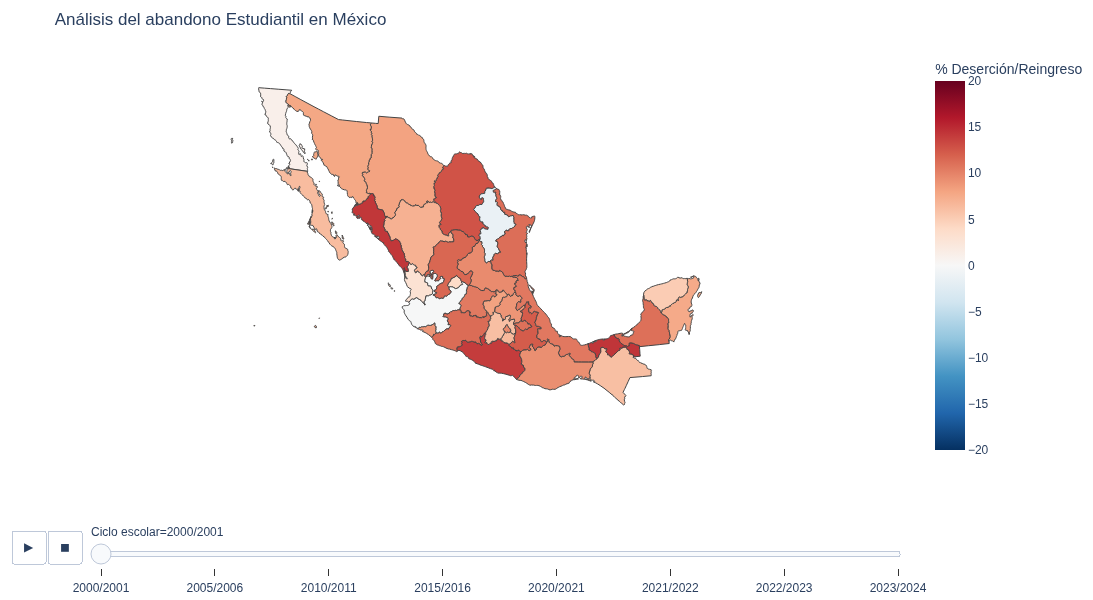

In [7]:
repo_url = 'https://raw.githubusercontent.com/angelnmara/geojson/master/mexicoHigh.json'

figura = px.choropleth(
       desercion_estatal,
       geojson=repo_url,
       locations='Entidad federativa',
       featureidkey='properties.name',
       color='Tasa de Deserción',
       animation_frame='Ciclo escolar',
       scope="north america",
       color_continuous_scale="RdBu_r", 
       range_color=[-20, 20], 
       labels={'Tasa de Deserción': '% Deserción/Reingreso'},
       title='Análisis del abandono Estudiantil en México',
       width=800,  
       height=600   
)


figura.update_geos(
       fitbounds="locations", 
       visible=False
)

figura.update_layout(
       margin={"r":0,"t":50,"l":0,"b":0}, 
)

figura.show()